## Análisis y Modelado Predictivo de Sargazo, República Dominicana.
Fuentes: CMEMS (NFAI/OLCI diario, variables oceánicas anfc). Periodo: 2024-2026.

## Configuración del área de estudio
Coordenadas usadas para recortar todos los productos CMEMS.  
north = 20.582  
south = 16.870  
west  = -71.89  
east  = -67.98  

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import statsmodels.api as sm
import dask
import dask.array as da
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras import layers

## Verificación del flag de calidad NFAI
#Se revisan los metadatos del flag antes de usarlo, ya que se detectó que el _FillValue coincide con el valor de "sargazo confirmado" (32767), lo que obliga a abrir el archivo con mask_and_scale=False para leerlo correctamente.

In [2]:
#chequeo flags
#se sustituye casa archivo de la temporada a procesar
archivo = "cmems_obs-mob_glo_bgc_nrt_mr_olci_P1D-i_nfai-flag_nfai_71.89W-67.98W_16.87N-20.58N_2024-03-01-2024-10-31.nc"

ds = xr.open_dataset(archivo, mask_and_scale=False)

print(ds["flag_nfai"].attrs)

flag_values = ds["flag_nfai"].attrs["flag_values"]
flag_meanings = ds["flag_nfai"].attrs["flag_meanings"].split()

flag_dict = dict(zip(flag_meanings, flag_values))
print(flag_dict)

valor_sargazo = flag_dict["valid_observation"]
mask_sargazo = (ds["flag_nfai"] == valor_sargazo)

#las flags son las mismas para los 3 archivos "no_observations_or_cloud_or_land": 1, "algae_free_ocean": 0, "valid_observation": 32767

{'_FillValue': np.int16(32767), 'flag_meanings': 'no_observations_or_cloud_or_land algae_free_ocean valid_observation', 'flag_values': array([    1,     0, 32767]), 'long_name': 'Normalized Floating Algae Index Flag', 'standard_name': 'status_flag', 'units': '1'}
{'no_observations_or_cloud_or_land': np.int64(1), 'algae_free_ocean': np.int64(0), 'valid_observation': np.int64(32767)}


## Archivos fuente por temporada
Un archivo NFAI por año (marzo-octubre), descargados por separado debido al tamaño del producto diario OLCI.

## Función de procesamiento por bloques
Procesa el archivo por lotes de días (batch_size) para evitar cargar la grilla completa (1485x1565 px/día) en memoria. Calcula % de cobertura, NFAI máximo y NFAI promedio usando el flag oficial (== 32767) en vez de un umbral arbitrario.

In [3]:
def procesar_temporada(archivo, batch_size=5):
    """
    Procesa un archivo NFAI+flag de una temporada completa, por bloques,
    sin cargar el archivo entero a memoria.
    Retorna un DataFrame con una fila por día.
    """
    # se abren dos veces el mismo archivo:
    # - ds: decodificado normal, para valores continuos de nfai (-0.5, 0.13, etc.)
    # - ds_raw: sin decodificar, para leer el flag correctamente
    ds = xr.open_dataset(archivo, chunks={"time": batch_size})
    ds_raw = xr.open_dataset(archivo, mask_and_scale=False, chunks={"time": batch_size})

    n_dias = ds.dims["time"]
    resultados = []

    for inicio in range(0, n_dias, batch_size):
        fin = min(inicio + batch_size, n_dias)

        nfai_bloque = ds["nfai"].isel(time=slice(inicio, fin)).compute()
        flag_bloque = ds_raw["flag_nfai"].isel(time=slice(inicio, fin)).compute()

        for j in range(fin - inicio):
            dia_nfai = nfai_bloque.isel(time=j)
            dia_flag = flag_bloque.isel(time=j)

            mask_sargazo = (dia_flag == 32767)
            mask_valido  = (dia_flag != 1)  # excluye nube/tierra/sin dato

            n_sargazo = int(mask_sargazo.sum())
            n_valido  = int(mask_valido.sum())
            pct = (n_sargazo / n_valido * 100) if n_valido > 0 else np.nan

            nfai_en_sargazo = dia_nfai.where(mask_sargazo)
            nfai_max = float(nfai_en_sargazo.max()) if n_sargazo > 0 else np.nan
            nfai_mean = float(nfai_en_sargazo.mean()) if n_sargazo > 0 else np.nan

            resultados.append({
                "time": pd.Timestamp(nfai_bloque.time.values[j]),
                "n_pixeles_sargazo": n_sargazo,
                "n_pixeles_validos": n_valido,
                "pct_cobertura": pct,
                "nfai_max": nfai_max,
                "nfai_mean_sargazo": nfai_mean,
            })

        print(f"  Días {inicio}-{fin} de {n_dias} procesados")

        del nfai_bloque, flag_bloque

    ds.close()
    ds_raw.close()

    return pd.DataFrame(resultados)

In [6]:
#se sustituye casa archivo de la temporada a procesar
#cmems_obs-mob_glo_bgc_nrt_mr_olci_P1D-i_nfai-flag_nfai_71.89W-67.98W_16.87N-20.58N_2024-03-01-2024-10-31.nc
#cmems_obs-mob_glo_bgc_nrt_mr_olci_P1D-i_nfai-flag_nfai_71.89W-67.98W_16.87N-20.58N_2025-03-01-2025-10-31.nc
#cmems_obs-mob_glo_bgc_nrt_mr_olci_P1D-i_nfai-flag_nfai_71.89W-67.98W_16.87N-20.58N_2026-03-01-2026-07-05.nc
df_temporada = procesar_temporada("cmems_obs-mob_glo_bgc_nrt_mr_olci_P1D-i_nfai-flag_nfai_71.89W-67.98W_16.87N-20.58N_2026-03-01-2026-07-05.nc")
#se sustituye nombre de archivo al año de la temporada#
df_temporada.to_csv("nfai_temporada_2026.csv", index=False)  #se justa el nombre al año real
print(df_temporada.describe())

C:\Users\PC\AppData\Local\Temp\ipykernel_15356\3833228505.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_dias = ds.dims["time"]


  Días 0-5 de 127 procesados
  Días 5-10 de 127 procesados
  Días 10-15 de 127 procesados
  Días 15-20 de 127 procesados
  Días 20-25 de 127 procesados
  Días 25-30 de 127 procesados
  Días 30-35 de 127 procesados
  Días 35-40 de 127 procesados
  Días 40-45 de 127 procesados
  Días 45-50 de 127 procesados
  Días 50-55 de 127 procesados
  Días 55-60 de 127 procesados
  Días 60-65 de 127 procesados
  Días 65-70 de 127 procesados
  Días 70-75 de 127 procesados
  Días 75-80 de 127 procesados
  Días 80-85 de 127 procesados
  Días 85-90 de 127 procesados
  Días 90-95 de 127 procesados
  Días 95-100 de 127 procesados
  Días 100-105 de 127 procesados
  Días 105-110 de 127 procesados
  Días 110-115 de 127 procesados
  Días 115-120 de 127 procesados
  Días 120-125 de 127 procesados
  Días 125-127 de 127 procesados
                      time  n_pixeles_sargazo  n_pixeles_validos  \
count                  127         127.000000       1.270000e+02   
mean   2026-05-03 00:00:00       10337.456693   

## Consolidación del histórico NFAI (2024-2026)

In [7]:
df_2024 = pd.read_csv("nfai_temporada_2024.csv", parse_dates=["time"])
df_2025 = pd.read_csv("nfai_temporada_2025.csv", parse_dates=["time"])
df_2026 = pd.read_csv("nfai_temporada_2026.csv", parse_dates=["time"])

df_nfai_completo = pd.concat([df_2024, df_2025, df_2026], ignore_index=True)
df_nfai_completo = df_nfai_completo.sort_values("time").drop_duplicates(subset="time")

print(f"Total días: {len(df_nfai_completo)}")
print(f"Rango: {df_nfai_completo['time'].min()} → {df_nfai_completo['time'].max()}")

Total días: 617
Rango: 2024-03-01 00:00:00 → 2026-07-05 00:00:00


## Carga de variables oceánicas (SST, salinidad, nutrientes, corrientes)
Promediadas espacialmente sobre el área de estudio. nut/curr/sal incluyen dimensión "depth" (se usa isel(depth=0), capa superficial).

In [8]:
nut  = xr.open_dataset("cmems_mod_glo_bgc-nut_anfc_0.25deg_P1D-m_1782969794466.nc")
sst  = xr.open_dataset("cmems_mod_glo_phy_anfc_0.083deg-sst-anomaly_P1D-m_1782970080532.nc")
curr = xr.open_dataset("cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m_1782970230828.nc")
sal  = xr.open_dataset("cmems_mod_glo_phy-so_anfc_0.083deg_P1D-m_1782970289319.nc")

nut_r  = nut.isel(depth=0)
curr_r = curr.isel(depth=0)
sal_r  = sal.isel(depth=0)

no3_series = nut_r["no3"].mean(dim=["latitude", "longitude"], skipna=True)
po4_series = nut_r["po4"].mean(dim=["latitude", "longitude"], skipna=True)
si_series  = nut_r["si"].mean(dim=["latitude", "longitude"], skipna=True)
fe_series  = nut_r["fe"].mean(dim=["latitude", "longitude"], skipna=True)

sst_series = sst["sea_surface_temperature_anomaly"].mean(dim=["latitude", "longitude"], skipna=True)

uo_series = curr_r["uo"].mean(dim=["latitude", "longitude"], skipna=True)
vo_series = curr_r["vo"].mean(dim=["latitude", "longitude"], skipna=True)

sal_series = sal_r["so"].mean(dim=["latitude", "longitude"], skipna=True)

df_no3 = no3_series.to_dataframe(name="no3").reset_index().drop(columns=["depth"], errors="ignore")
df_po4 = po4_series.to_dataframe(name="po4").reset_index().drop(columns=["depth"], errors="ignore")
df_si  = si_series.to_dataframe(name="si").reset_index().drop(columns=["depth"], errors="ignore")
df_fe  = fe_series.to_dataframe(name="fe").reset_index().drop(columns=["depth"], errors="ignore")
df_uo  = uo_series.to_dataframe(name="uo").reset_index().drop(columns=["depth"], errors="ignore")
df_vo  = vo_series.to_dataframe(name="vo").reset_index().drop(columns=["depth"], errors="ignore")
df_sal = sal_series.to_dataframe(name="salinity").reset_index().drop(columns=["depth"], errors="ignore")
df_sst = sst_series.to_dataframe(name="sst_anomaly").reset_index()

for nombre, df_temp in {"no3": df_no3, "po4": df_po4, "si": df_si, "fe": df_fe,
                          "uo": df_uo, "vo": df_vo, "salinity": df_sal}.items():
    print(f"{nombre}: {df_temp.shape}, rango {df_temp['time'].min()} → {df_temp['time'].max()}")

no3: (1714, 2), rango 2021-11-01 00:00:00 → 2026-07-11 00:00:00
po4: (1714, 2), rango 2021-11-01 00:00:00 → 2026-07-11 00:00:00
si: (1714, 2), rango 2021-11-01 00:00:00 → 2026-07-11 00:00:00
fe: (1714, 2), rango 2021-11-01 00:00:00 → 2026-07-11 00:00:00
uo: (1502, 2), rango 2022-06-01 00:00:00 → 2026-07-11 00:00:00
vo: (1502, 2), rango 2022-06-01 00:00:00 → 2026-07-11 00:00:00
salinity: (1502, 2), rango 2022-06-01 00:00:00 → 2026-07-11 00:00:00


## Merge del NFAI con variables oceánicas por fecha

In [9]:
df_final = df_nfai_completo.merge(df_sst, on="time", how="inner")
df_final = df_final.merge(df_sal, on="time", how="inner")
df_final = df_final.merge(df_no3, on="time", how="inner")
df_final = df_final.merge(df_po4, on="time", how="inner")
df_final = df_final.merge(df_si,  on="time", how="inner")
df_final = df_final.merge(df_fe,  on="time", how="inner")
df_final = df_final.merge(df_uo,  on="time", how="inner")
df_final = df_final.merge(df_vo,  on="time", how="inner")

In [10]:
df_final

,time,n_pixeles_sargazo,n_pixeles_validos,pct_cobertura,nfai_max,nfai_mean_sargazo,sst_anomaly,salinity,no3,po4,si,fe,uo,vo
0,2024-03-01,307,1159401,0.026479,0.0370,0.014302,0.047252,36.033276,6.303739,0.678812,8.073559,0.001058,-0.185396,0.010311
1,2024-03-02,2,813245,0.000246,0.0025,0.002450,0.036782,36.052147,6.301392,0.678512,8.041080,0.001057,-0.161825,0.022791
2,2024-03-03,19,928113,0.002047,0.0248,0.006779,0.051414,36.065128,6.301320,0.677968,8.008496,0.001056,-0.144795,0.033075
3,2024-03-04,5,648467,0.000771,0.1178,0.063700,0.078582,36.066429,6.310385,0.677865,8.030035,0.001054,-0.132345,0.044841
4,2024-03-05,1,1115592,0.000090,0.0326,0.032600,0.095371,36.063431,6.317676,0.677311,8.057435,0.001051,-0.107653,0.038421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,2026-07-01,18311,1207271,1.516727,0.2852,0.019128,0.733208,36.274307,5.868207,0.651315,8.999480,0.001153,-0.134612,0.074346
613,2026-07-02,24485,1270430,1.927300,0.4339,0.030234,0.714024,36.274818,5.870822,0.651708,8.995437,0.001148,-0.129150,0.067513
614,2026-07-03,5,9722,0.051430,0.0092,0.004040,0.737333,36.277843,5.879002,0.652345,9.019889,0.001149,-0.138212,0.060195
615,2026-07-04,13016,502590,2.589785,0.4024,0.015011,0.818058,36.280029,5.886481,0.652608,9.066116,0.001160,-0.149216,0.051556


## Limpieza - días sin observación satelital (n_pixeles_validos == 0)
Se descartan solo los días donde el satélite no tuvo NINGUNA observación válida (nublado al 100%); no se rellenan con 0 porque no equivale a "sin sargazo", sino a "sin información".

In [11]:
df_final = df_final.replace([np.inf, -np.inf], np.nan)

print(f"Filas antes: {len(df_final)}")
print(f"Días sin observación válida (n_pixeles_validos == 0): {(df_final['n_pixeles_validos'] == 0).sum()}")

#drop por falta de observaciónes del satélite
df_final = df_final.dropna(subset=["pct_cobertura"])

# Para los días con observación pero sin sargazo detectado
df_final["nfai_max"] = df_final["nfai_max"].fillna(0)
df_final["nfai_mean_sargazo"] = df_final["nfai_mean_sargazo"].fillna(0)

print(f"Filas después: {len(df_final)}")

Filas antes: 617
Días sin observación válida (n_pixeles_validos == 0): 8
Filas después: 609


## EDA preliminar (antes de la depuración de outliers/artefactos)
Nota: esta tabla se recalcula más abajo (sección final) tras remover el artefacto de octubre 2024 y los días de baja cobertura satelital. Se conserva aquí para dejar evidencia del efecto de la limpieza.

In [12]:
variables = ["pct_cobertura", "nfai_max", "nfai_mean_sargazo",
             "sst_anomaly", "salinity", "no3", "po4", "si", "fe", "uo", "vo"]

In [13]:
# 1. Tabla descriptiva
tabla_descriptiva = df_final[variables].describe().T
tabla_descriptiva["missing"] = df_final[variables].isna().sum()
print(tabla_descriptiva)

                   count       mean       std        min        25%  \
pct_cobertura      609.0   1.457764  3.933747   0.000000   0.029832   
nfai_max           609.0   0.221579  0.180529   0.000000   0.056000   
nfai_mean_sargazo  609.0   0.021425  0.018070   0.000000   0.009535   
sst_anomaly        608.0   0.258761  0.200559  -0.190291   0.128922   
salinity           609.0  36.088715  0.267188  35.138123  35.995106   
no3                609.0   6.102783  0.265334   5.688312   5.925904   
po4                609.0   0.662901  0.013008   0.641518   0.652398   
si                 609.0   8.843768  0.740109   7.278038   8.314283   
fe                 609.0   0.001101  0.000044   0.001026   0.001065   
uo                 609.0  -0.087687  0.057223  -0.240361  -0.126500   
vo                 609.0   0.063659  0.035369  -0.081166   0.040867   

                         50%        75%        max  missing  
pct_cobertura       0.366085   1.647764  75.484654        0  
nfai_max            0.1

In [14]:
fila_faltante = df_final[df_final["sst_anomaly"].isna()]
print(fila_faltante[["time"]])

df_final = df_final.dropna(subset=["sst_anomaly"])
print(f"Filas después: {len(df_final)}")

          time
214 2024-10-01
Filas después: 608


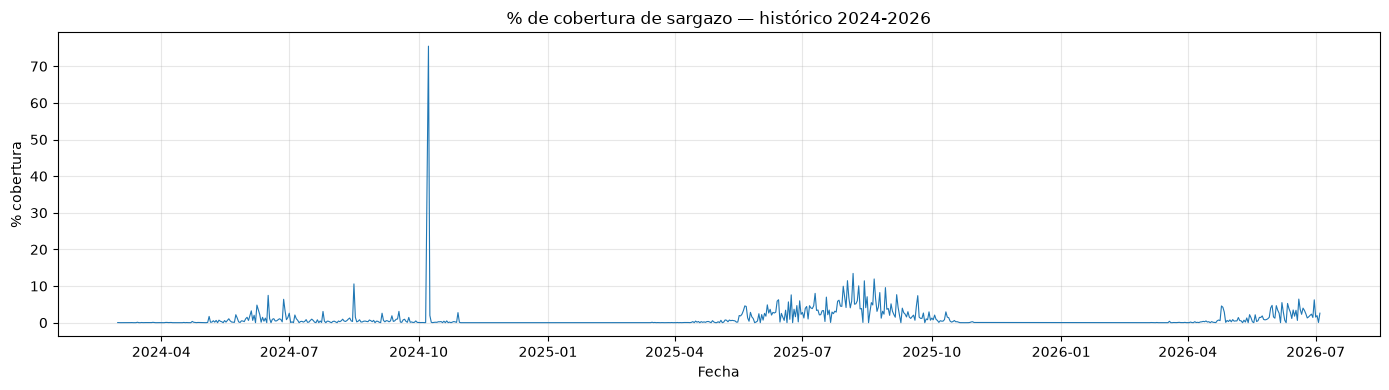

In [15]:
#2. Serie de tiempo
plt.figure(figsize=(14, 4))
plt.plot(df_final["time"], df_final["pct_cobertura"], linewidth=0.8)
plt.title("% de cobertura de sargazo — histórico 2024-2026")
plt.xlabel("Fecha"); plt.ylabel("% cobertura")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

<Figure size 1200x500 with 0 Axes>

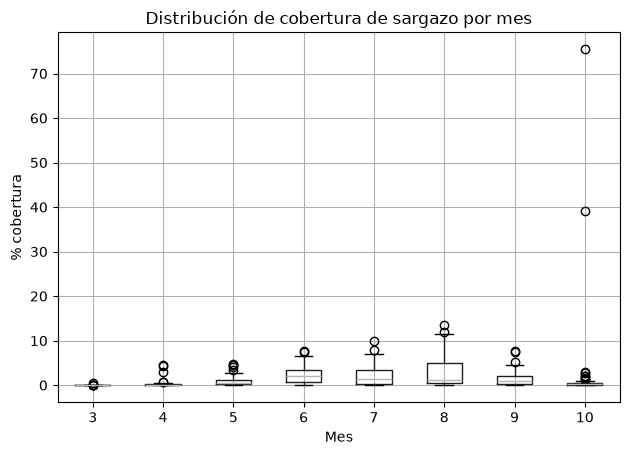

In [16]:
#3. Estacionalidad por mes
df_final["mes"] = df_final["time"].dt.month
plt.figure(figsize=(12, 5))
df_final.boxplot(column="pct_cobertura", by="mes")
plt.title("Distribución de cobertura de sargazo por mes")
plt.suptitle(""); plt.xlabel("Mes"); plt.ylabel("% cobertura")
plt.tight_layout(); plt.show()

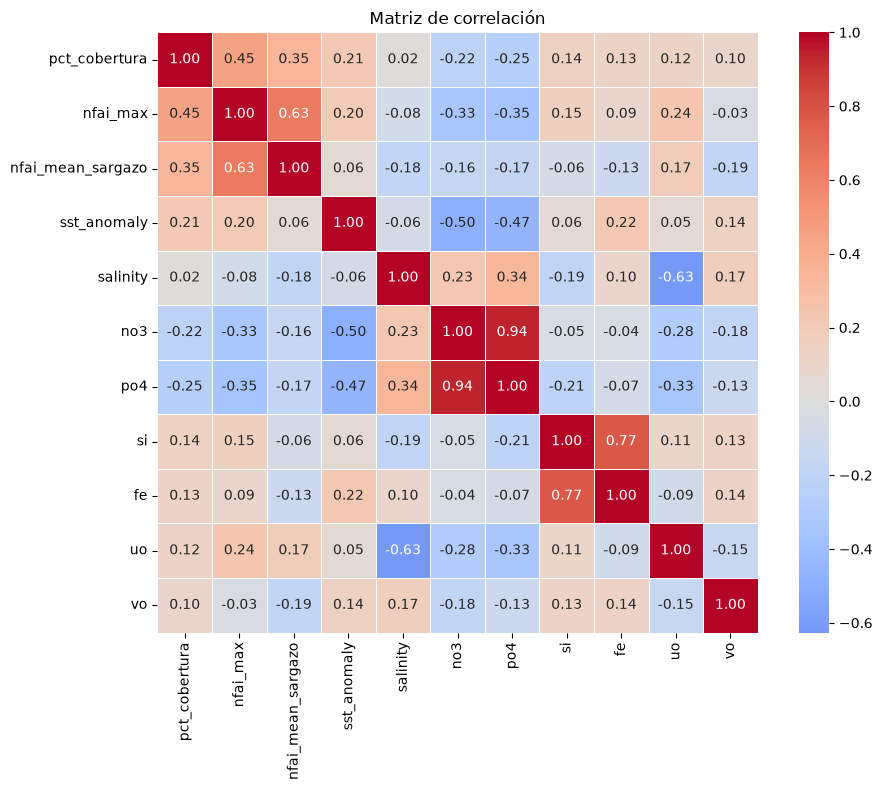

pct_cobertura        1.000000
nfai_max             0.448955
nfai_mean_sargazo    0.349018
sst_anomaly          0.212831
si                   0.144787
fe                   0.126590
uo                   0.120896
vo                   0.098757
salinity             0.018288
no3                 -0.217853
po4                 -0.245494
Name: pct_cobertura, dtype: float64


In [17]:
#4. Correlación
corr = df_final[variables].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Matriz de correlación")
plt.tight_layout(); plt.show()
print(corr["pct_cobertura"].sort_values(ascending=False))

## Detección de valores atípicos en pct_cobertura
Se investigan los 10 días con mayor % de cobertura para distinguir eventos reales de arribazón vs. posibles artefactos del sensor.

In [18]:
top10 = df_final.nlargest(10, "pct_cobertura")[["time", "pct_cobertura", "nfai_max"]]
print(top10)

          time  pct_cobertura  nfai_max
221 2024-10-08      75.484654    1.0000
220 2024-10-07      39.116337    1.0000
403 2025-08-06      13.444547    0.4983
418 2025-08-21      11.933378    0.3136
399 2025-08-02      11.463579    0.4976
411 2025-08-14      11.427056    0.4970
168 2024-08-16      10.584312    0.2180
407 2025-08-10      10.054335    0.5024
396 2025-07-30       9.948033    0.4634
426 2025-08-29       9.570219    0.4709


Nota: nfai_max = 1.0000 exacto (sin decimales) en varios días es sospechoso de saturación del sensor; se investiga a continuación.

In [19]:
print((df_final["nfai_max"] == 1.0).sum())
print(df_final[df_final["nfai_max"] == 1.0][["time", "pct_cobertura", "nfai_max"]])

2
          time  pct_cobertura  nfai_max
220 2024-10-07      39.116337       1.0
221 2024-10-08      75.484654       1.0


### Caso: octubre 2024, ¿evento real o artefacto?
Se revisa la evolución día a día alrededor del pico para verificar si hubo acumulación gradual (esperada en un evento real) o un salto abrupto (señal de artefacto).

In [20]:
ventana = df_final[(df_final["time"] >= "2024-10-01") & (df_final["time"] <= "2024-10-15")]
print(ventana[["time", "pct_cobertura", "nfai_max", "n_pixeles_sargazo", "n_pixeles_validos"]])

          time  pct_cobertura  nfai_max  n_pixeles_sargazo  n_pixeles_validos
215 2024-10-02       0.028243    0.3224                341            1207387
216 2024-10-03       0.039503    0.3315                524            1326470
217 2024-10-04       0.041918    0.2258                464            1106933
218 2024-10-05       0.016277    0.0557                 88             540628
219 2024-10-06       0.025071    0.1578                244             973231
220 2024-10-07      39.116337    1.0000             393021            1004749
221 2024-10-08      75.484654    1.0000             790273            1046932
222 2024-10-09       1.957363    0.2919              22870            1168409
223 2024-10-10       0.101956    0.0638               1277            1252499
224 2024-10-11       0.008401    0.1748                109            1297495
225 2024-10-12       0.088486    0.0417                649             733446
226 2024-10-13       0.122189    0.1653               1495      

Visualización espacial del NFAI el 2024-10-08 para inspeccionar el patrón, se busca una mancha costera coherente (real) vs. cobertura uniforme en toda la escena (artefacto).

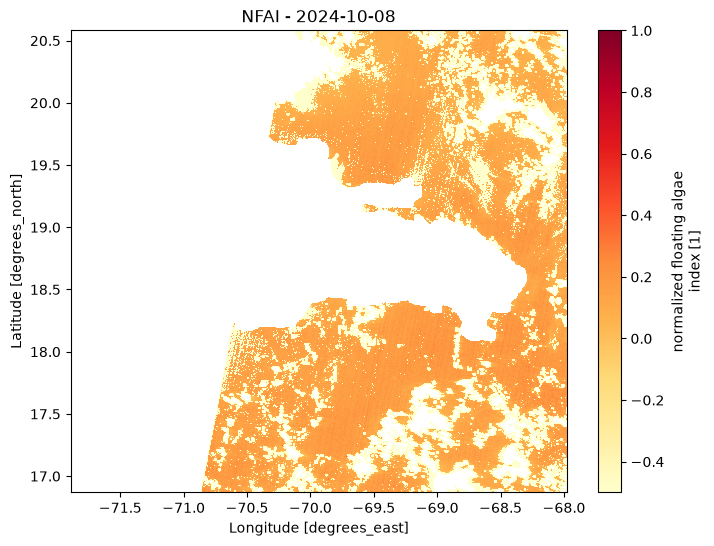

In [21]:
ds_oct = xr.open_dataset("cmems_obs-mob_glo_bgc_nrt_mr_olci_P1D-i_nfai-flag_nfai_71.89W-67.98W_16.87N-20.58N_2024-03-01-2024-10-31.nc",
                          chunks={"time": 1})

dia = ds_oct["nfai"].sel(time="2024-10-08").compute()

plt.figure(figsize=(8, 6))
dia.plot(cmap="YlOrRd", vmin=-0.5, vmax=1.0)
plt.title("NFAI - 2024-10-08")
plt.show()

Comparación visual con un evento similar en 2025 (2025-10-02).

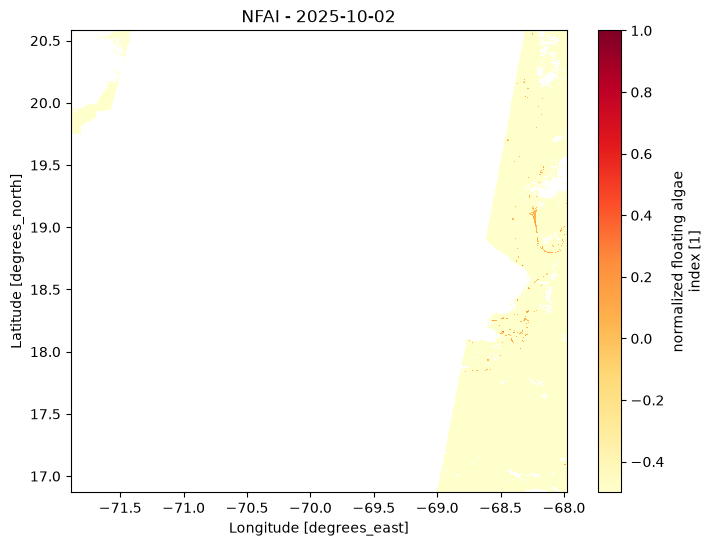

In [22]:
ds_oct1 = xr.open_dataset("cmems_obs-mob_glo_bgc_nrt_mr_olci_P1D-i_nfai-flag_nfai_71.89W-67.98W_16.87N-20.58N_2025-03-01-2025-10-31.nc",
                          chunks={"time": 1})

dia1 = ds_oct1["nfai"].sel(time="2025-10-02").compute()

plt.figure(figsize=(8, 6))
dia1.plot(cmap="YlOrRd", vmin=-0.5, vmax=1.0)
plt.title("NFAI - 2025-10-02")
plt.show()

Verificación cuantitativa de que ambos días son datos distintos y no un error de indexación repitiendo el mismo array.

In [23]:
ds_2024 = xr.open_dataset(
    "cmems_obs-mob_glo_bgc_nrt_mr_olci_P1D-i_nfai-flag_nfai_71.89W-67.98W_16.87N-20.58N_2024-03-01-2024-10-31.nc",
    chunks={"time": 1})

ds_2025 = xr.open_dataset(
    "cmems_obs-mob_glo_bgc_nrt_mr_olci_P1D-i_nfai-flag_nfai_71.89W-67.98W_16.87N-20.58N_2025-03-01-2025-10-31.nc",   # <-- pon aquí el nombre real
    chunks={"time": 1})

dia_2024 = ds_2024["nfai"].sel(time="2024-10-08").compute()
dia_2025 = ds_2025["nfai"].sel(time="2025-10-02").compute()

print("¿Identicos?", bool((dia_2024.values == dia_2025.values).all()))
print("Diferencia máxima:", float(np.nanmax(np.abs(dia_2024.values - dia_2025.values))))

¿Identicos? False
Diferencia máxima: 0.8311


In [24]:
dia_limpio = df_final.nsmallest(5, "pct_cobertura")[["time", "pct_cobertura"]]
print(dia_limpio)

         time  pct_cobertura
43 2024-04-13            0.0
44 2024-04-14            0.0
48 2024-04-18            0.0
63 2024-05-03            0.0
71 2024-05-11            0.0


### Control: comparación contra un día de baja cobertura confirmada
Se verifica que el patrón "naranja" no aparezca también en un día sin sargazo, para descartar sesgo estructural del índice en aguas costeras.

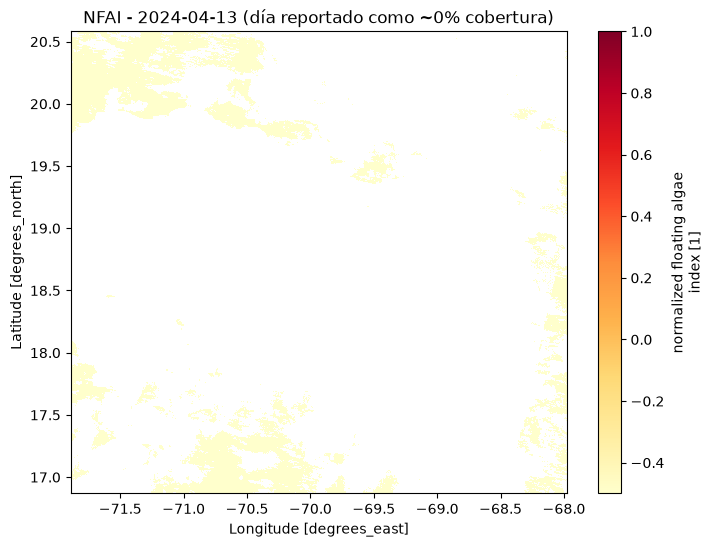

In [25]:
fecha_limpia = "2024-04-13" 

dia_test = ds_2024["nfai"].sel(time=fecha_limpia).compute()

plt.figure(figsize=(8, 6))
dia_test.plot(cmap="YlOrRd", vmin=-0.5, vmax=1.0)
plt.title(f"NFAI - {fecha_limpia} (día reportado como ~0% cobertura)")
plt.show()

### Verificación de coherencia temporal - octubre 2025
Se aplica la misma prueba que a octubre 2024 (¿hay acumulación gradual?) antes de aceptar o descartar el pico.

In [26]:
ventana_2025 = df_final[
    (df_final["time"] >= "2025-09-25") & (df_final["time"] <= "2025-10-10")
]
print(ventana_2025[["time", "pct_cobertura", "nfai_max", "n_pixeles_sargazo", "n_pixeles_validos"]])

          time  pct_cobertura  nfai_max  n_pixeles_sargazo  n_pixeles_validos
453 2025-09-25       2.640603    0.3368               2572              97402
454 2025-09-26       0.002653    0.0024                  3             113088
455 2025-09-27       1.024843    0.3996               9990             974783
456 2025-09-28       0.805048    0.3620               5358             665550
457 2025-09-29       2.953349    0.3280              36280            1228436
458 2025-09-30       0.661246    0.2364               8661            1309800
459 2025-10-01       1.250937    0.4039              16630            1329403
460 2025-10-02       0.784005    0.3829               2810             358416
461 2025-10-03       2.074765    0.5252              30051            1448405
462 2025-10-04       0.905434    0.3938              11267            1244375
463 2025-10-05       0.601294    0.4895               7528            1251967
464 2025-10-06       0.077593    0.2645                136      

### Búsqueda de otros posibles artefactos en todo el histórico
Se identifican los mayores cambios día a día en pct_cobertura para revisar si hay más saltos abruptos como el de octubre 2024.

In [27]:
df_final["cambio_diario"] = df_final["pct_cobertura"].diff().abs()
saltos_grandes = df_final.nlargest(10, "cambio_diario")[["time", "pct_cobertura", "cambio_diario"]]
print(saltos_grandes)

          time  pct_cobertura  cambio_diario
222 2024-10-09       1.957363      73.527292
220 2024-10-07      39.116337      39.091265
221 2024-10-08      75.484654      36.368318
411 2025-08-14      11.427056      11.362706
168 2024-08-16      10.584312      10.263452
169 2024-08-17       1.490684       9.093628
404 2025-08-07       5.042734       8.401813
360 2025-06-24       0.000000       7.591509
403 2025-08-06      13.444547       7.560600
107 2024-06-16       7.460450       7.459516


### Conclusión, remoción del artefacto confirmado
Se excluyen 2024-10-07 y 2024-10-08: patrón de cobertura uniforme en toda la escena, sin acumulación previa/posterior, consistente con artefacto de corrección atmosférica o saturación del sensor (no con un evento real de arribazón).

In [28]:
fechas_artefacto = ["2024-10-07", "2024-10-08"]
mask_artefacto = df_final["time"].isin(pd.to_datetime(fechas_artefacto))
print(f"Filas a remover: {mask_artefacto.sum()}")

df_final = df_final[~mask_artefacto].reset_index(drop=True)
print(f"Filas finales: {len(df_final)}")

Filas a remover: 2
Filas finales: 606


Se verifica que el resto de los saltos grandes se explican por variabilidad en la nubosidad diaria (n_pixeles_validos), no por errores de sensor.

In [29]:
casos_revisar = ["2025-08-14", "2024-08-16", "2024-08-17", "2025-08-07", "2025-06-24", "2025-08-06", "2024-06-16"]

revision = df_final[df_final["time"].isin(pd.to_datetime(casos_revisar))]
print(revision[["time", "pct_cobertura", "n_pixeles_sargazo", "n_pixeles_validos"]])

          time  pct_cobertura  n_pixeles_sargazo  n_pixeles_validos
103 2024-06-16       7.460450              83405            1117962
164 2024-08-16      10.584312              56940             537966
165 2024-08-17       1.490684              20121            1349783
352 2025-06-24       0.000000                  0                569
395 2025-08-06      13.444547             100322             746191
396 2025-08-07       5.042734              62052            1230523
403 2025-08-14      11.427056             158186            1384311


### Filtro de calidad, mínimo de grilla observada por día
Días con muy pocos píxeles válidos (ej. 2025-06-24, con apenas 569 de 2,324,025 píxeles) no son estadísticamente representativos del área. Se calcula el % de grilla observada por día.

In [30]:
total_pixeles_grilla = 1485 * 1565
print(f"Total píxeles en la grilla: {total_pixeles_grilla:,}")

df_final["pct_grilla_valida"] = df_final["n_pixeles_validos"] / total_pixeles_grilla * 100

print(df_final["pct_grilla_valida"].describe())
print(f"\nDías con menos de 5% de la grilla observada:")
print(df_final[df_final["pct_grilla_valida"] < 5][["time", "n_pixeles_validos", "pct_grilla_valida", "pct_cobertura"]])

dias_poco_confiables = df_final[df_final["pct_grilla_valida"] < 5]
print(f"Total de días con menos de 5% de la grilla observada: {len(dias_poco_confiables)}")
print(f"Eso representa el {len(dias_poco_confiables)/len(df_final)*100:.1f}% del dataset")

Total píxeles en la grilla: 2,324,025
count    606.000000
mean      32.526539
std       18.805791
min        0.002582
25%       15.457579
50%       36.510902
75%       48.954820
max       62.465206
Name: pct_grilla_valida, dtype: float64

Días con menos de 5% de la grilla observada:
          time  n_pixeles_validos  pct_grilla_valida  pct_cobertura
17  2024-03-18              24587           1.057949       0.044739
42  2024-04-14               3312           0.142511       0.000000
46  2024-04-18               2177           0.093674       0.000000
50  2024-04-22              84024           3.615452       0.003570
54  2024-04-26              19622           0.844311       0.010193
..         ...                ...                ...            ...
577 2026-06-06                738           0.031755       0.000000
581 2026-06-10               1720           0.074010       0.000000
585 2026-06-14              68698           2.955992       1.142682
596 2026-06-25              51992   

Se prueban distintos umbrales de corte (1%, 2%, 5%, 10%) para elegir uno defendible; no hay un punto de corte "natural" evidente en la distribución.

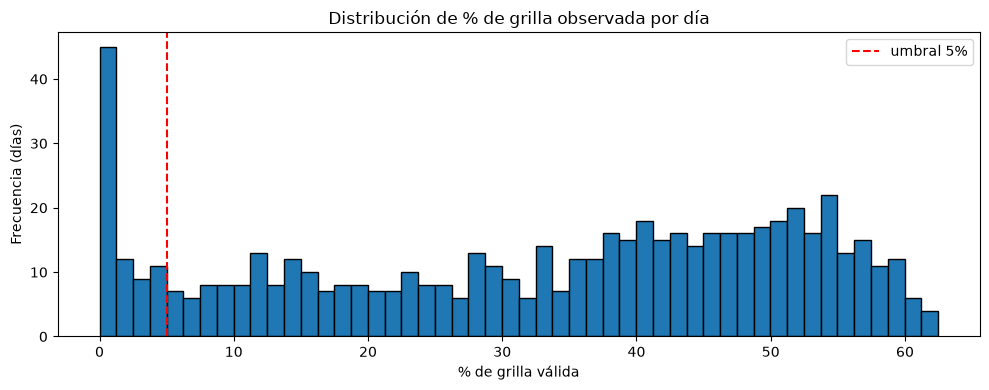

Umbral 1%: elimina 42 días (6.9%)
Umbral 2%: elimina 48 días (7.9%)
Umbral 5%: elimina 77 días (12.7%)
Umbral 10%: elimina 106 días (17.5%)


In [31]:
plt.figure(figsize=(10, 4))
plt.hist(df_final["pct_grilla_valida"], bins=50, edgecolor="black")
plt.axvline(5, color="red", linestyle="--", label="umbral 5%")
plt.title("Distribución de % de grilla observada por día")
plt.xlabel("% de grilla válida")
plt.ylabel("Frecuencia (días)")
plt.legend()
plt.tight_layout()
plt.show()

for umbral_test in [1, 2, 5, 10]:
    n = (df_final["pct_grilla_valida"] < umbral_test).sum()
    print(f"Umbral {umbral_test}%: elimina {n} días ({n/len(df_final)*100:.1f}%)")

Se aplica el umbral de 5% (elimina 12.7% de los días) como balance entre calidad y tamaño de muestra. Dataset final: 529 días (2024-03-01 a 2026-07-04).

In [32]:
print(f"Filas antes: {len(df_final)}")

df_final = df_final[df_final["pct_grilla_valida"] >= 5].reset_index(drop=True)

print(f"Filas después: {len(df_final)}")
print(f"Rango de fechas: {df_final['time'].min()} → {df_final['time'].max()}")

Filas antes: 606
Filas después: 529
Rango de fechas: 2024-03-01 00:00:00 → 2026-07-04 00:00:00


## EDA final, dataset depurado
(Reemplaza la sección preliminar de arriba: sin el artefacto de octubre 2024 y sin días de observación insuficiente.

In [33]:
variables = ["pct_cobertura", "nfai_max", "nfai_mean_sargazo",
             "sst_anomaly", "salinity", "no3", "po4", "si", "fe", "uo", "vo"]

tabla_descriptiva = df_final[variables].describe().T
tabla_descriptiva["missing"] = df_final[variables].isna().sum()
print(tabla_descriptiva)

                   count       mean       std        min        25%  \
pct_cobertura      529.0   1.400570  2.069566   0.000000   0.052387   
nfai_max           529.0   0.245877  0.169788   0.000000   0.097800   
nfai_mean_sargazo  529.0   0.023188  0.016508   0.000000   0.011718   
sst_anomaly        529.0   0.258683  0.200569  -0.190291   0.135949   
salinity           529.0  36.082764  0.264539  35.149151  35.994957   
no3                529.0   6.100962  0.264778   5.688312   5.925973   
po4                529.0   0.662876  0.012925   0.641761   0.652467   
si                 529.0   8.821075  0.748463   7.278038   8.295832   
fe                 529.0   0.001099  0.000044   0.001026   0.001064   
uo                 529.0  -0.087011  0.057411  -0.216033  -0.125858   
vo                 529.0   0.062389  0.035360  -0.081166   0.039273   

                         50%        75%        max  missing  
pct_cobertura       0.474077   2.058517  13.444547        0  
nfai_max            0.2

### Estacionalidad por año, evidencia de patrón recurrente
Compara el promedio mensual entre 2024, 2025 y 2026 para verificar si la temporada alta (jun-oct) se repite consistentemente entre años, confirmando el comportamiento estacional.

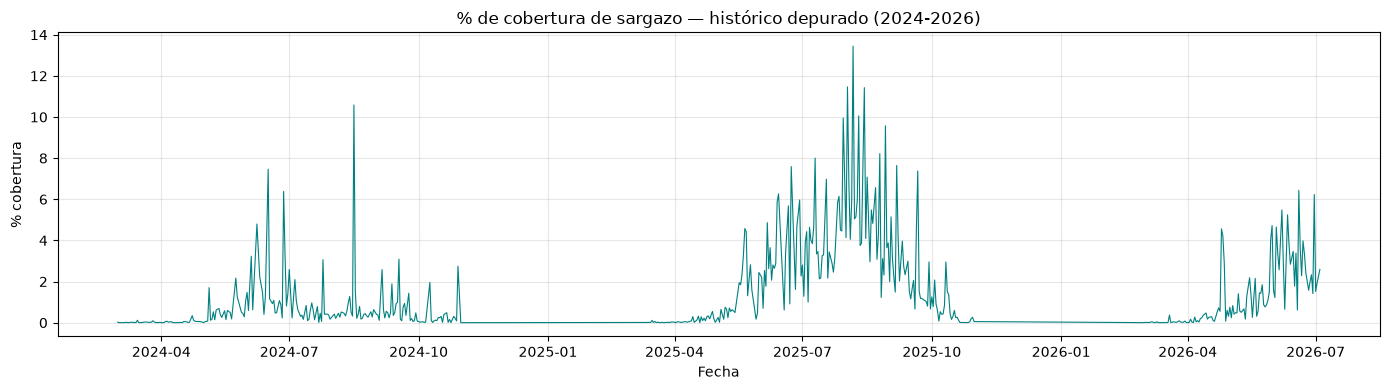

In [34]:
plt.figure(figsize=(14, 4))
plt.plot(df_final["time"], df_final["pct_cobertura"], linewidth=0.8, color="teal")
plt.title("% de cobertura de sargazo — histórico depurado (2024-2026)")
plt.xlabel("Fecha"); plt.ylabel("% cobertura")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

<Figure size 1200x500 with 0 Axes>

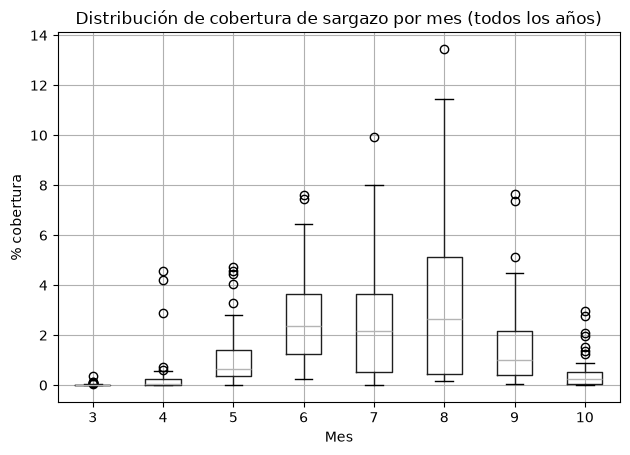

In [35]:
df_final["mes"] = df_final["time"].dt.month
df_final["año"] = df_final["time"].dt.year

plt.figure(figsize=(12, 5))
df_final.boxplot(column="pct_cobertura", by="mes")
plt.title("Distribución de cobertura de sargazo por mes (todos los años)")
plt.suptitle(""); plt.xlabel("Mes"); plt.ylabel("% cobertura")
plt.tight_layout(); plt.show()

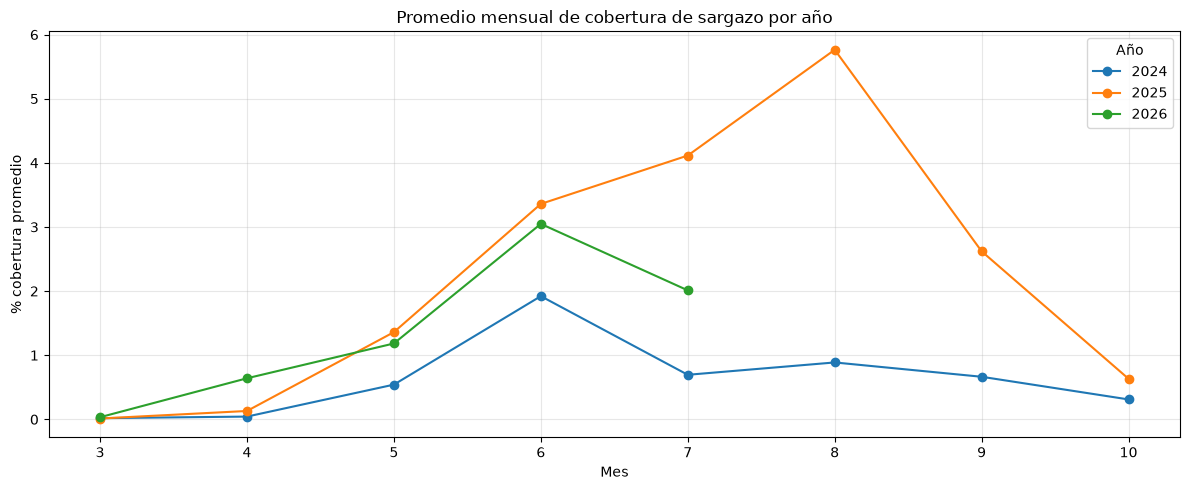

In [36]:
plt.figure(figsize=(12, 5))
for año in sorted(df_final["año"].unique()):
    datos_año = df_final[df_final["año"] == año]
    promedio_mensual = datos_año.groupby("mes")["pct_cobertura"].mean()
    plt.plot(promedio_mensual.index, promedio_mensual.values, marker="o", label=str(año))

plt.title("Promedio mensual de cobertura de sargazo por año")
plt.xlabel("Mes"); plt.ylabel("% cobertura promedio")
plt.legend(title="Año")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

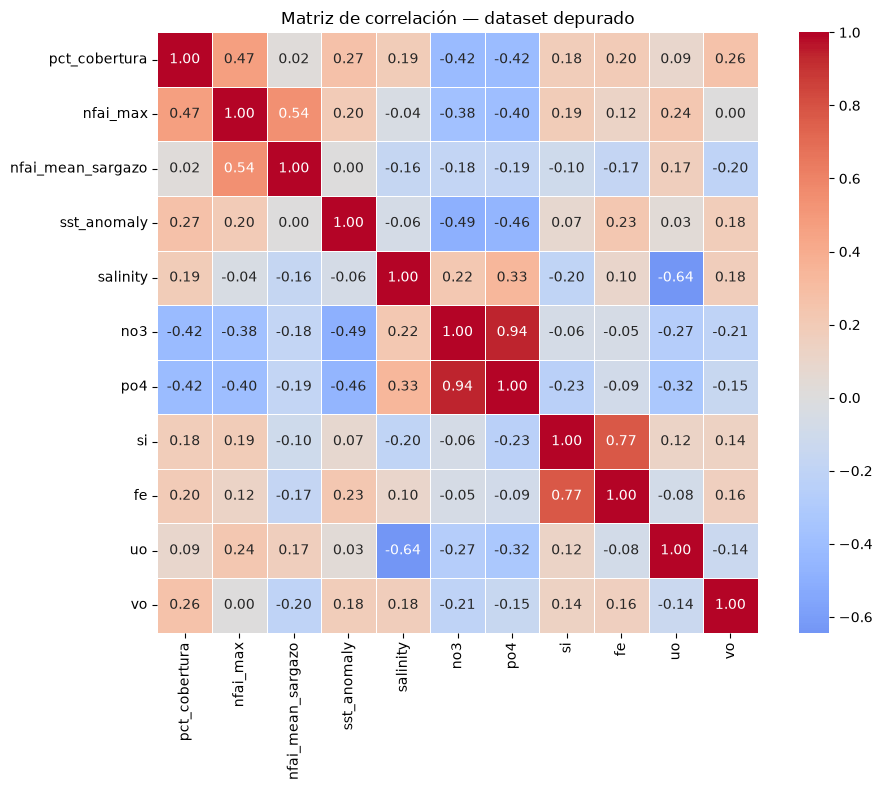


Correlación con pct_cobertura (ordenada):
pct_cobertura        1.000000
nfai_max             0.469115
sst_anomaly          0.273859
vo                   0.256807
fe                   0.201615
salinity             0.191369
si                   0.179290
uo                   0.093547
nfai_mean_sargazo    0.021194
po4                 -0.417421
no3                 -0.421844
Name: pct_cobertura, dtype: float64


In [37]:
corr = df_final[variables].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Matriz de correlación — dataset depurado")
plt.tight_layout(); plt.show()

print("\nCorrelación con pct_cobertura (ordenada):")
print(corr["pct_cobertura"].sort_values(ascending=False))

## Modelado predictivo, clasificación de eventos de arribazón
Se define bloom_event como los días en el percentil 80 superior de pct_cobertura (~20% de los días), respondiendo directamente a la Hipótesis 3.

In [38]:
threshold = df_final["pct_cobertura"].quantile(0.80)
df_final["bloom_event"] = (df_final["pct_cobertura"] > threshold).astype(int)

print(f"Umbral (percentil 80): {threshold:.4f}")
print(df_final["bloom_event"].value_counts())
print(f"Proporción de eventos: {df_final['bloom_event'].mean():.2%}")

Umbral (percentil 80): 2.6039
bloom_event
0    423
1    106
Name: count, dtype: int64
Proporción de eventos: 20.04%


Se seleccionan variables sin colinealidad severa (se excluyen no3 y si por correlación >0.77 con po4 y fe respectivamente) y se estandarizan para estabilidad numérica del modelo

In [39]:
features = ["sst_anomaly", "salinity", "po4", "fe", "uo", "vo"]  # se deja fuera no3 (po4) y si (fe)

X = df_final[features]
y = df_final["bloom_event"]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features, index=X.index)

### Regresión logística, modelo completo

In [40]:
import statsmodels.api as sm

logit_model = sm.Logit(y, sm.add_constant(X_scaled)).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.305444
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            bloom_event   No. Observations:                  529
Model:                          Logit   Df Residuals:                      522
Method:                           MLE   Df Model:                            6
Date:                Mon, 27 Jul 2026   Pseudo R-squ.:                  0.3902
Time:                        19:56:11   Log-Likelihood:                -161.58
converged:                       True   LL-Null:                       -264.99
Covariance Type:            nonrobust   LLR p-value:                 6.699e-42
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -2.5971      0.246    -10.557      0.000      -3.079      -2.115
sst_anomaly     0.2104    

### Evaluación del modelo
AUC-ROC: 0.901. el modelo identifica bien los días normales (recall 95%), pero detecta solo el 58% de los eventos reales de arribazón.

In [41]:
y_pred_prob = logit_model.predict(sm.add_constant(X_scaled))
y_pred = (y_pred_prob > 0.5).astype(int)

print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))
print(f"AUC-ROC: {roc_auc_score(y, y_pred_prob):.3f}")

[[400  23]
 [ 44  62]]
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       423
           1       0.73      0.58      0.65       106

    accuracy                           0.87       529
   macro avg       0.82      0.77      0.79       529
weighted avg       0.87      0.87      0.87       529

AUC-ROC: 0.901


## Random forest

In [42]:
df_final = df_final.sort_values("time").reset_index(drop=True)

split_idx = int(len(df_final) * 0.8)
train = df_final.iloc[:split_idx]
test = df_final.iloc[split_idx:]

X_train, y_train = train[features], train["bloom_event"]
X_test, y_test = test[features], test["bloom_event"]

print(f"Train: {len(train)} días ({train['time'].min().date()} → {train['time'].max().date()})")
print(f"Test:  {len(test)} días ({test['time'].min().date()} → {test['time'].max().date()})")

Train: 423 días (2024-03-01 → 2026-03-07)
Test:  106 días (2026-03-08 → 2026-07-04)


In [43]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.3f}")

importancias = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportancia de variables:")
print(importancias)

Random Forest
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        87
           1       1.00      0.05      0.10        19

    accuracy                           0.83       106
   macro avg       0.91      0.53      0.50       106
weighted avg       0.86      0.83      0.76       106

AUC-ROC: 0.669

Importancia de variables:
po4            0.302559
sst_anomaly    0.191654
salinity       0.144961
fe             0.144008
vo             0.131367
uo             0.085450
dtype: float64


In [44]:
scale = (y_train == 0).sum() / (y_train == 1).sum()  # balancea clases

xgb_model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale, random_state=42, eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.3f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.82      1.00      0.90        87
           1       0.00      0.00      0.00        19

    accuracy                           0.82       106
   macro avg       0.41      0.50      0.45       106
weighted avg       0.67      0.82      0.74       106

AUC-ROC: 0.528


D:\Apps\anaconda3\envs\sargazo\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Apps\anaconda3\envs\sargazo\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Apps\anaconda3\envs\sargazo\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## LSTM

In [45]:
def crear_secuencias(X, y, ventana=7):
    Xs, ys = [], []
    for i in range(len(X) - ventana):
        Xs.append(X[i:i+ventana])
        ys.append(y[i+ventana])
    return np.array(Xs), np.array(ys)

X_train_arr = scaler.transform(train[features])  # reutiliza el scaler ya ajustado
X_test_arr = scaler.transform(test[features])

ventana = 7
X_train_seq, y_train_seq = crear_secuencias(X_train_arr, y_train.values, ventana)
X_test_seq, y_test_seq = crear_secuencias(X_test_arr, y_test.values, ventana)

lstm_model = tf.keras.Sequential([
    layers.Input(shape=(ventana, len(features))),
    layers.LSTM(16),
    layers.Dense(1, activation="sigmoid")
])
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

lstm_model.fit(X_train_seq, y_train_seq, epochs=30, batch_size=16, verbose=0)

y_prob_lstm = lstm_model.predict(X_test_seq).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

print("=== LSTM ===")
print(classification_report(y_test_seq, y_pred_lstm))
print(f"AUC-ROC: {roc_auc_score(y_test_seq, y_prob_lstm):.3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
=== LSTM ===
              precision    recall  f1-score   support

           0       0.79      0.88      0.83        80
           1       0.00      0.00      0.00        19

    accuracy                           0.71        99
   macro avg       0.39      0.44      0.41        99
weighted avg       0.64      0.71      0.67        99

AUC-ROC: 0.584


## Comparación

In [46]:
X_train_scaled = scaler.transform(train[features])
X_test_scaled = scaler.transform(test[features])

# Se reentrena la Regresión Logística solo con el set de entrenamiento (train),
# y se evalúa sobre el set de prueba (test) — igual que Random Forest, XGBoost y LSTM 
# para que la comparación entre los 4 modelos sea justa (todos evaluados sobre datos
# que el modelo nunca vio durante el entrenamiento).
logit_model_cv = sm.Logit(y_train, sm.add_constant(X_train_scaled)).fit(disp=False)

X_test_const = sm.add_constant(X_test_scaled, has_constant="add")
y_prob_logit_test = logit_model_cv.predict(X_test_const)

comparacion = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest", "XGBoost", "LSTM"],
    "AUC-ROC": [
        roc_auc_score(y_test, y_prob_logit_test),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test_seq, y_prob_lstm),
    ]
}).sort_values("AUC-ROC", ascending=False)

print(comparacion)

                Modelo   AUC-ROC
0  Regresión Logística  0.764065
1        Random Forest  0.669087
3                 LSTM  0.584211
2              XGBoost  0.527526


In [56]:
y_pred_logit_test = (y_prob_logit_test > 0.5).astype(int)

print("Regresión Logística — evaluación fuera de muestra (test set)")
print(confusion_matrix(y_test, y_pred_logit_test))
print(classification_report(y_test, y_pred_logit_test))

=== Regresión Logística — evaluación fuera de muestra (test set) ===
[[85  2]
 [17  2]]
              precision    recall  f1-score   support

           0       0.83      0.98      0.90        87
           1       0.50      0.11      0.17        19

    accuracy                           0.82       106
   macro avg       0.67      0.54      0.54       106
weighted avg       0.77      0.82      0.77       106



## Interpretación de resultados

La Regresión Logística obtuvo el mejor desempeño (AUC-ROC = 0.764), superando a
los modelos de mayor complejidad algorítmica (Random Forest, LSTM y XGBoost).

Esto es consistente con el tamaño limitado del conjunto de entrenamiento (~420
observaciones diarias): algoritmos con mayor capacidad de ajuste como Random
Forest, XGBoost y LSTM requieren volúmenes de datos considerablemente mayores
para generalizar correctamente, y en este caso muestran señales de sobreajuste
al conjunto de entrenamiento (particularmente XGBoost, con un AUC-ROC de 0.528,
cercano al de una clasificación aleatoria).

En consecuencia, se selecciona la Regresión Logística como modelo final del
sistema, priorizando su capacidad de generalización sobre la complejidad
algorítmica, un resultado que refuerza la importancia de ajustar la
complejidad del modelo al volumen de datos disponible, en lugar de asumir que
un algoritmo más sofisticado produce necesariamente mejores resultados.

## Verificación de robustez - sensibilidad al umbral de bloom_event
Se evalúa si la elección del percentil 80 como definición del evento de arribazón
es razonable, comparándola contra percentiles 75 y 90 bajo el mismo split temporal.

In [53]:
# Prueba de sensibilidad del umbral de bloom_event (percentil 75 y 90)
# Reutiliza el mismo pipeline de entrenamiento/evaluación que la Regresión Logística final

resultados_sensibilidad = []

for percentil in [0.75, 0.80, 0.90]:
    threshold_p = df_final["pct_cobertura"].quantile(percentil)
    bloom_event_p = (df_final["pct_cobertura"] > threshold_p).astype(int)

    # split cronológico
    y_train_p = bloom_event_p.iloc[:split_idx]
    y_test_p  = bloom_event_p.iloc[split_idx:]

    # reentrena la logística con el nuevo target, mismas variables ya estandarizadas
    logit_p = sm.Logit(y_train_p, sm.add_constant(X_train_scaled)).fit(disp=False)
    X_test_const_p = sm.add_constant(X_test_scaled, has_constant="add")
    y_prob_p = logit_p.predict(X_test_const_p)

    auc_p = roc_auc_score(y_test_p, y_prob_p)

    resultados_sensibilidad.append({
        "Percentil": f"P{int(percentil*100)}",
        "Umbral (% cobertura)": round(threshold_p, 4),
        "Eventos (train)": int(y_train_p.sum()),
        "Eventos (test)": int(y_test_p.sum()),
        "AUC-ROC (test)": round(auc_p, 3)})

df_sensibilidad = pd.DataFrame(resultados_sensibilidad)
print(df_sensibilidad)

  Percentil  Umbral (% cobertura)  Eventos (train)  Eventos (test)  \
0       P75                2.0585              106              26   
1       P80                2.6039               87              19   
2       P90                4.1501               45               8   

   AUC-ROC (test)  
0           0.825  
1           0.764  
2           0.666  


Modelo con percentil de 75, para validar uso de percentil 80.

In [55]:
# Modelo de exploración con percentil 75 

# Redefinir bloom_event con P75
threshold_75 = df_final["pct_cobertura"].quantile(0.75)
bloom_event_75 = (df_final["pct_cobertura"] > threshold_75).astype(int)

print(f"Umbral (percentil 75): {threshold_75:.4f}")
print(bloom_event_75.value_counts())
print(f"Proporción de eventos: {bloom_event_75.mean():.2%}")

# split cronologico
y_train_75 = bloom_event_75.iloc[:split_idx]
y_test_75  = bloom_event_75.iloc[split_idx:]

# Entrenar la regresión logística 
logit_75 = sm.Logit(y_train_75, sm.add_constant(X_train_scaled)).fit()
print(logit_75.summary())

# Evaluar sobre el test set
X_test_const_75 = sm.add_constant(X_test_scaled, has_constant="add")
y_prob_75 = logit_75.predict(X_test_const_75)
y_pred_75 = (y_prob_75 > 0.5).astype(int)

print("\n=== Evaluación P75 (test set) ===")
print(confusion_matrix(y_test_75, y_pred_75))
print(classification_report(y_test_75, y_pred_75))
print(f"AUC-ROC: {roc_auc_score(y_test_75, y_prob_75):.3f}")

Umbral (percentil 75): 2.0585
pct_cobertura
0    397
1    132
Name: count, dtype: int64
Proporción de eventos: 24.95%
Optimization terminated successfully.
         Current function value: 0.301992
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          pct_cobertura   No. Observations:                  423
Model:                          Logit   Df Residuals:                      416
Method:                           MLE   Df Model:                            6
Date:                Mon, 27 Jul 2026   Pseudo R-squ.:                  0.4636
Time:                        20:20:45   Log-Likelihood:                -127.74
converged:                       True   LL-Null:                       -238.14
Covariance Type:            nonrobust   LLR p-value:                 7.028e-45
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

## Semáforo

In [47]:
playas = {
    "Punta Cana":          (18.58, -68.37),
    "Bavaro Beach":        (18.71, -68.45),
    "Macao":               (18.79, -68.57),
    "Uvero Alto":          (18.82, -68.60),
    "Juanillo":            (18.48, -68.39),
    "Bayahibe":            (18.37, -68.84),
    "Dominicus":           (18.35, -68.83),
    "Isla Saona":          (18.15, -68.68),
    "La Romana (Minitas)": (18.41, -68.97),
    "Caleta":              (18.44, -69.00),
    "Juan Dolio":          (18.42, -69.42),
    "Guayacanes":          (18.45, -69.43),
    "Boca Chica":          (18.45, -69.61),}

In [48]:
def simular_variables(fecha):
    """
    Genera valores simulados de las variables oceánicas para una fecha
    fuera del rango de datos reales, usando la distribución histórica
    del mismo mes (climatología simple) como base.
    """
    fecha = pd.Timestamp(fecha)
    mes = fecha.month

    datos_mes = df_final[df_final["time"].dt.month == mes]

    if len(datos_mes) == 0:
        datos_mes = df_final  # fallback: usa todo el histórico si el mes no tiene suficientes datos

    vals = []
    for col in features:
        media = datos_mes[col].mean()
        std = datos_mes[col].std()
        valor_simulado = np.random.normal(media, std)
        vals.append(valor_simulado)

    return vals

In [49]:
def extraer_variables(lat, lon, fecha, permitir_simulacion=True):
    fecha = pd.Timestamp(fecha)

    rango_min = pd.Timestamp(sst.time.values.min())
    rango_max = pd.Timestamp(sst.time.values.max())

    if rango_min <= fecha <= rango_max:
        sst_val = float(sst["sea_surface_temperature_anomaly"].sel(
            time=fecha, latitude=lat, longitude=lon, method="nearest"))
        sal_val = float(sal_r["so"].sel(
            time=fecha, latitude=lat, longitude=lon, method="nearest"))
        po4_val = float(nut_r["po4"].sel(
            time=fecha, latitude=lat, longitude=lon, method="nearest"))
        fe_val  = float(nut_r["fe"].sel(
            time=fecha, latitude=lat, longitude=lon, method="nearest"))
        uo_val  = float(curr_r["uo"].sel(
            time=fecha, latitude=lat, longitude=lon, method="nearest"))
        vo_val  = float(curr_r["vo"].sel(
            time=fecha, latitude=lat, longitude=lon, method="nearest"))
        return [sst_val, sal_val, po4_val, fe_val, uo_val, vo_val], False  # False = no es simulado

    elif permitir_simulacion:
        return simular_variables(fecha), True  # True = es simulado

    else:
        raise ValueError(f"Fecha fuera de rango disponible ({rango_min.date()} a {rango_max.date()})")

In [50]:
def predecir_riesgo(playa, fecha):
    lat, lon = playas[playa]
    vals, es_simulado = extraer_variables(lat, lon, fecha)

    X_playa = pd.DataFrame([vals], columns=features)
    X_scaled = scaler.transform(X_playa)
    X_scaled = sm.add_constant(X_scaled, has_constant="add")

    prob = logit_model.predict(X_scaled)[0]
    return prob, clasificar_semaforo(prob), es_simulado

In [51]:
def clasificar_semaforo(prob):
    if prob > 0.6:
        return "🔴 ALTO"
    elif prob > 0.3:
        return "🟡 MEDIO"
    else:
        return "🟢 BAJO"

In [52]:
def semaforo_por_fecha(fecha):
    resultados = []
    algun_simulado = False
    for playa in playas:
        prob, nivel, es_simulado = predecir_riesgo(playa, fecha)
        algun_simulado = algun_simulado or es_simulado
        resultados.append({"playa": playa, "probabilidad": round(prob, 3), "riesgo": nivel})

    df_resultado = pd.DataFrame(resultados).sort_values("probabilidad", ascending=False)

    print(f"Pronóstico de riesgo de sargazo — {pd.Timestamp(fecha).date()}")
    if algun_simulado:
        print("Fecha fuera del rango de datos reales — valores oceánicos SIMULADOS (climatología histórica por mes), no son un pronóstico real.\n")
    else:
        print("Basado en datos oceánicos reales (CMEMS).\n")

    return df_resultado

semaforo_por_fecha("2027-06-01")

Pronóstico de riesgo de sargazo — 2027-06-01
Fecha fuera del rango de datos reales — valores oceánicos SIMULADOS (climatología histórica por mes), no son un pronóstico real.



,playa,probabilidad,riesgo
3,Uvero Alto,0.894,🔴 ALTO
4,Juanillo,0.830,🔴 ALTO
8,La Romana (Minitas),0.665,🔴 ALTO
0,Punta Cana,0.452,🟡 MEDIO
12,Boca Chica,0.418,🟡 MEDIO
1,Bavaro Beach,0.417,🟡 MEDIO
7,Isla Saona,0.312,🟡 MEDIO
2,Macao,0.238,🟢 BAJO
6,Dominicus,0.211,🟢 BAJO
9,Caleta,0.186,🟢 BAJO
